# Détection d'Objets - 13/04/2026

Dans ce notebook, nous verrons comment l'IA peut être utilisée pour détecter des objets. Nous verrons deux approches : spécifiques et par VLM/LLM.

Comme toujours, toutes les cellules peuvent être executées dans l'ordre, mais essayez de prédire la sortie de chaque cellule avant de l'exécuter.
N'hésitez pas à jouer avec le code, le bidouiller pour tester des alternatives — c'est l'un des grands avantages d'utiliser un notebook.

In [ ]:
import cv2
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw
from PIL import ImageColor

import matplotlib.patches as patches


# Partie 1 - Modèle Spécifique : YOLO



❓ Avant de commencer, que savez-vous de la strutcure d'un réseau de neurones ?

> * Réseaux de neurones convolutionnels (CNN) : Les CNN utilisent des filtres pour extraire progressivement des caractéristiques des images, en passant de traits simples (comme les bords) à des attributs complexes pour la classification ou la détection d'objets.
Ils sont spécifiquement conçus pour traiter des données structurées en grille comme les images. Les CNN sont largement utilisés pour la classification d'images, la détection d'objets, la segmentation sémantique et la génération d'images.

<img src="https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Ftse4.mm.bing.net%2Fth%3Fid%3DOIP.F5A9npwC1qzLEn-rV59WlAHaDq%26pid%3DApi&f=1&ipt=b681764f327db8665c1f7bc338f6f0ae270e6d84572f2ba13082962b4d320968&ipo=images" title="cnn2"/>


Leurs usages varient : 
- détection d'objet
- segmentation sémantique
- classification


Commençons par employer un modèle spécifique de détection d'objets : YOLO (maintenant dans sa 8ème itération), qui est un CNN.

Entraîné sur des photos contemporaines, YOLO est capable de détecter 80 classes d'objets.

Pour le mettre en usage, nous allons simplement diviser la pipeline en deux étapes : 
- 1) La détection à proprement parler
- 2) L'affichage

Ici, la fonction `detect_objects()` prend en entrée un chemin vers une image, et extrait les 

In [46]:
def detect_objects(image_path):
    """
    Detect objects in an image using YOLOv8.
    
    Args:
        image_path: Path to the input image
    
    Returns:
        Detected objects and class labels.
    """
    # Load YOLO model
    model = YOLO('yolov8n.pt')  # Load the model
    
    # Read image
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Perform detection
    results = model(image_rgb)[0]
    
    # Create a copy of the image for drawing
    annotated_image = image_rgb.copy()
    
    # Generate random colors for classes
    np.random.seed(42)  # For consistent colors
    colors = np.random.randint(0, 255, size=(100, 3), dtype=np.uint8)

    # Process detections
    boxes = results.boxes

    return boxes, results.names, annotated_image, colors


In [45]:
detect_objects('./data/cours_14-04/cinema.jpeg')


0: 384x640 3 persons, 4 cars, 2 trucks, 1 handbag, 1 tie, 56.5ms
Speed: 2.3ms preprocess, 56.5ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)


(ultralytics.engine.results.Boxes object with attributes:
 
 cls: tensor([ 0.,  0.,  0.,  2., 26.,  7., 27.,  2.,  2.,  2.,  7.])
 conf: tensor([0.9251, 0.8884, 0.8264, 0.6385, 0.5916, 0.4594, 0.4572, 0.3381, 0.3008, 0.2696, 0.2647])
 data: tensor([[9.1581e+02, 8.4259e+01, 1.4446e+03, 1.0684e+03, 9.2509e-01, 0.0000e+00],
         [4.8195e+02, 2.3595e+02, 9.2941e+02, 1.0699e+03, 8.8844e-01, 0.0000e+00],
         [1.1107e+02, 7.0158e+02, 2.6989e+02, 1.0793e+03, 8.2641e-01, 0.0000e+00],
         [1.4562e+03, 7.8831e+02, 1.5729e+03, 9.1350e+02, 6.3849e-01, 2.0000e+00],
         [6.3053e+02, 7.1924e+02, 7.4441e+02, 9.8175e+02, 5.9159e-01, 2.6000e+01],
         [1.5249e+03, 5.3720e+02, 1.9193e+03, 1.0706e+03, 4.5941e-01, 7.0000e+00],
         [1.0948e+03, 3.5410e+02, 1.1812e+03, 6.3433e+02, 4.5715e-01, 2.7000e+01],
         [7.1370e-01, 8.9580e+02, 1.5499e+02, 1.0793e+03, 3.3809e-01, 2.0000e+00],
         [1.5227e+03, 6.9662e+02, 1.6658e+03, 1.0733e+03, 3.0081e-01, 2.0000e+00],
         [1.6

La fonction `show_results()` quant à elle ne fait que récuperer la sortie de `detect_objects()` pour l'afficher sur l'image originale.

In [ ]:

def show_results(image_path, confidence_threshold):
    # Read original image
    original_image = cv2.imread(image_path)
    original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
    
    # Get detection results
    boxes, class_names, annotated_image, colors = detect_objects(image_path)
    
    # Process each detected object and apply confidence threshold filtering
    class_labels = {}
    for box in boxes:
        # Get box coordinates
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        
        # Get confidence score
        confidence = float(box.conf[0])
        
        # Only show detections above confidence threshold
        if confidence > confidence_threshold:
            # Get class id and name
            class_id = int(box.cls[0])
            class_name = class_names[class_id]
            
            # Get color for this class
            color = colors[class_id % len(colors)].tolist()
            
            # Draw bounding box
            cv2.rectangle(annotated_image, (x1, y1), (x2, y2), color, 2)
            
            # Store class name and color for legend
            class_labels[class_name] = color

    # Create figure
    plt.figure(figsize=(15, 7))
    
    # Show original image
    plt.subplot(1, 2, 1)
    plt.title('Original Image')
    plt.imshow(original_image)
    plt.axis('off')
    
    # Show detection results
    plt.subplot(1, 2, 2)
    plt.title('Detected Objects')
    plt.imshow(annotated_image)
    plt.axis('off')

    # Create legend
    legend_handles = []
    for class_name, color in class_labels.items():
        normalized_color = np.array(color) / 255.0  # Normalize the color
        legend_handles.append(plt.Line2D([0], [0], marker='o', color='w', label=class_name,
                                           markerfacecolor=normalized_color, markersize=10))

    plt.legend(handles=legend_handles, loc='upper right', title='Classes')

    plt.tight_layout()
    plt.show()



❓ Quel est le rôle du paramètre `confidence_threshold` ?

*Votre réponse ici*


0: 384x640 3 persons, 4 cars, 2 trucks, 1 handbag, 1 tie, 52.7ms
Speed: 2.6ms preprocess, 52.7ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)


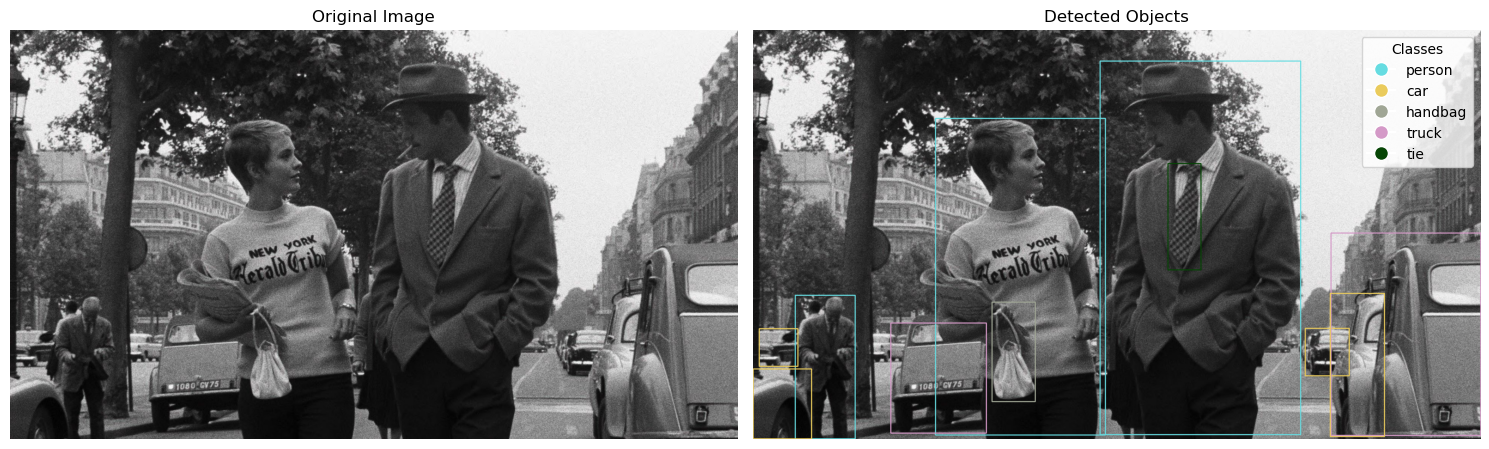

In [47]:
show_results('./data/cours_14-04/cinema.jpeg', confidence_threshold=0.2)

❗ Que se passe-t'il si nous regardons désormais du côté d'images non-photographiques ?


0: 640x608 1 person, 1 teddy bear, 78.9ms
Speed: 3.4ms preprocess, 78.9ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 608)


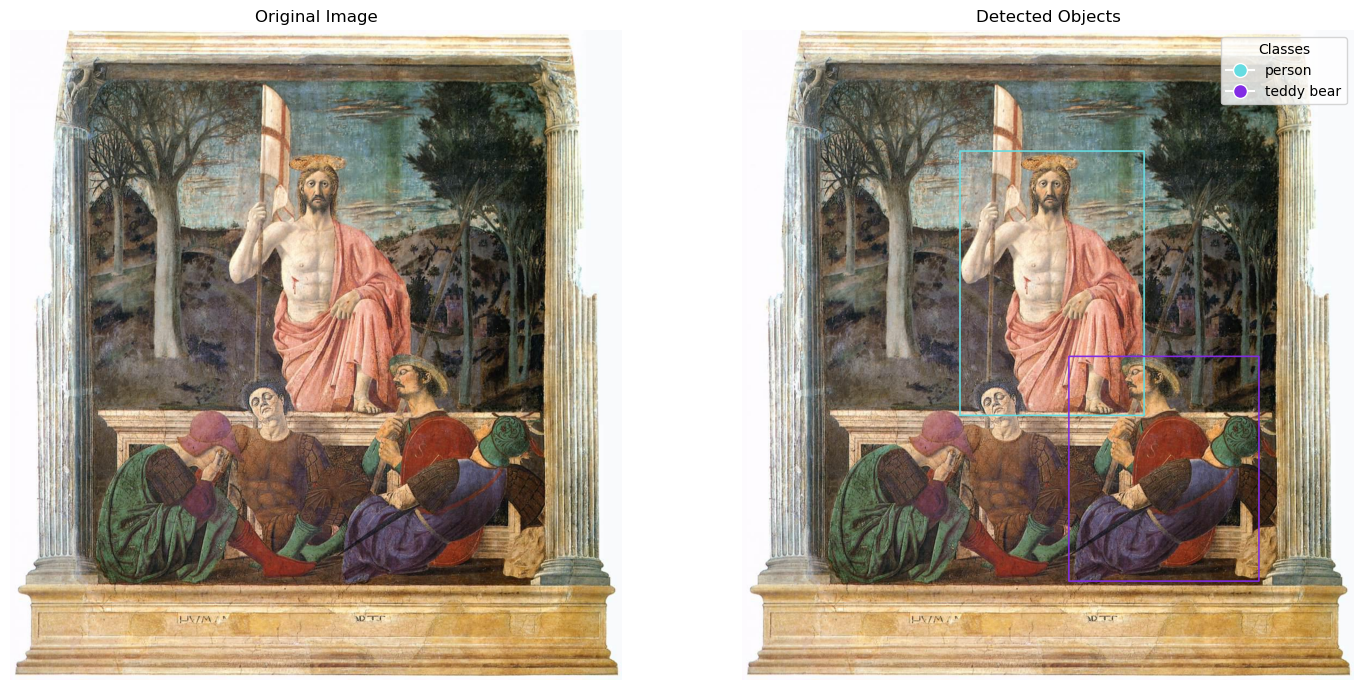

In [48]:
show_results('./data/cours_23-03/piero/31402.jpg', confidence_threshold=0.2)


0: 448x640 6 umbrellas, 1 kite, 55.0ms
Speed: 1.8ms preprocess, 55.0ms inference, 0.6ms postprocess per image at shape (1, 3, 448, 640)


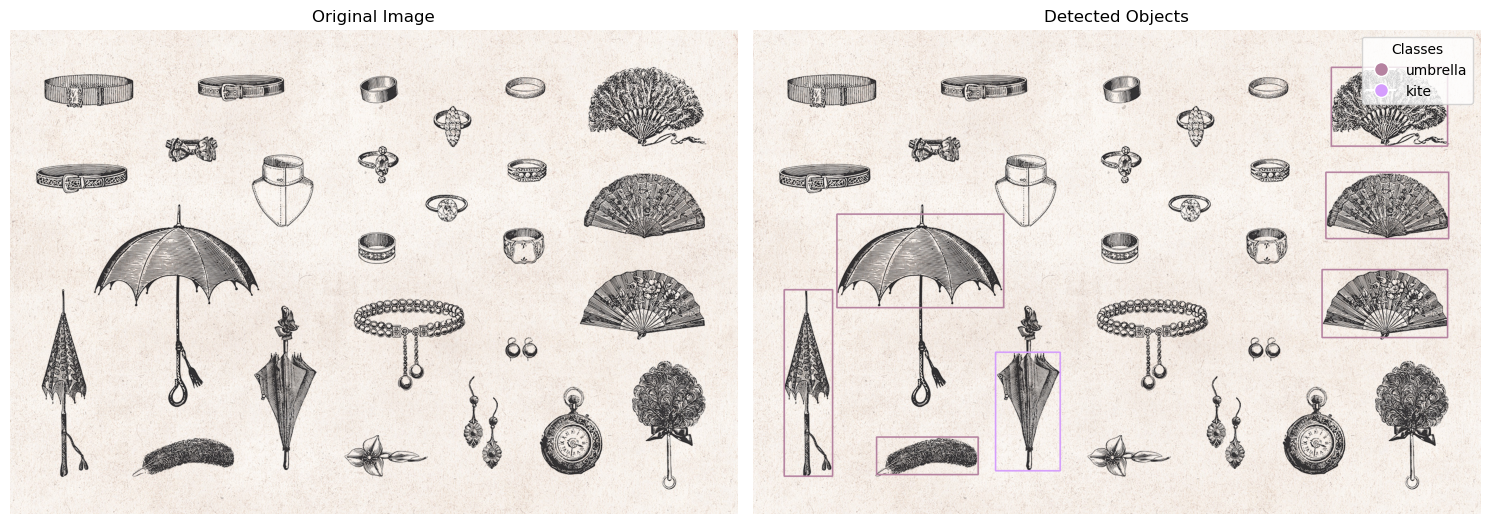

In [49]:
show_results('./data/cours_14-04/victorian_fashion2.png', confidence_threshold=0.2)

❓ Que que peut-on faire dans ces cas là ?

*Votre réponse ici*

# Partie 2 - Vision Language Models

Bien plus versatiles (et problématiques à bien des égards) sont les LLMs, et leur pendant visuel les VLMs.

❓ Que savez-vous des LLMs ? De leur fonctionnement, de leur entraînement ?

*Votre réponse ici*

Pour intéragir avec un LLM dans Python, la plupart des entreprises ont développé une API et une librairie Python correspondante.

Nous allons, à titre d'exemple, utiliser `Gemini` via la librairie `google.genai`:

❗ Pour cela, nous avons besoin d'une clé API. J'ai ici mis la mienne, mais à vous de replacer par la vôtre si vous utilisez cette API !

In [ ]:
from google import genai
from google.genai import types
from PIL import Image
import json
from io import BytesIO

# Ma clé API
client = genai.Client(api_key=YOUR_API_KEY_HERE)

Nous pouvons maintenant passer en argument n'importe quel *prompt*.

In [ ]:

response = client.models.generate_content(
    model="gemini-3-flash-preview", contents="Décris ce qu'est une image numérique en quelques phrases."
)
print(response.text)

Une image numérique est une représentation visuelle convertie en données informatiques pour être affichée sur un écran ou stockée sur un support. Elle est composée d'une multitude de petits carrés colorés appelés **pixels**, organisés selon une grille (matrice).

Chaque pixel possède une valeur numérique précise qui détermine sa couleur et son intensité. Plus le nombre de pixels est élevé, plus la définition de l'image est fine et détaillée.


❗ Si maintenant, je change le prompt de manière à lui donner des instructions de reconnaissance d'objet, et que je spécifie une image, alors Gemini peut tenter de détecter ce qui nous intéresse dans l'image :

In [62]:
prompt = "Detect the 2d bounding boxes of the different objects in this engraving (with “label” as topping description”)"  # @param {type:"string"}

image = './data/cours_14-04/victorian_fashion2.png'


im = Image.open(BytesIO(open(image, "rb").read()))
im.thumbnail([1024,1024], Image.Resampling.LANCZOS)

# Run model to find bounding boxes
response = client.models.generate_content(
    model="gemini-3-flash-preview",
    contents=[prompt, im],
    config = types.GenerateContentConfig(
        temperature=0.5,
        thinking_config=types.ThinkingConfig(
          thinking_budget=0
        )
    )
)


Quelques petites manipulations de l'output :

In [63]:
objects = eval('['+response.text.split('json\n[\n  ')[1].replace('`','').replace('\n','').replace('"label": "label": ','"label":'))

❓ Quel est le format de l'output ? Combien d'objets a-t-il détecté ?

In [64]:
objects

[{'box_2d': [759, 647, 907, 676], 'label': 'earring'},
 {'box_2d': [737, 728, 918, 814], 'label': 'pocket watch'},
 {'box_2d': [277, 35, 338, 161], 'label': 'belt'},
 {'box_2d': [297, 788, 431, 955], 'label': 'fan'},
 {'box_2d': [635, 680, 684, 701], 'label': 'earring'},
 {'box_2d': [259, 332, 407, 417], 'label': 'collar'},
 {'box_2d': [538, 42, 923, 107], 'label': 'umbrella'},
 {'box_2d': [241, 478, 318, 534], 'label': 'ring'},
 {'box_2d': [496, 783, 639, 955], 'label': 'fan'},
 {'box_2d': [409, 677, 484, 734], 'label': 'ring'},
 {'box_2d': [95, 258, 148, 376], 'label': 'belt'},
 {'box_2d': [571, 335, 909, 421], 'label': 'umbrella'},
 {'box_2d': [361, 116, 777, 342], 'label': 'umbrella'},
 {'box_2d': [93, 46, 161, 170], 'label': 'belt'},
 {'box_2d': [836, 459, 922, 573], 'label': 'brooch'},
 {'box_2d': [715, 622, 863, 651], 'label': 'earring'},
 {'box_2d': [684, 854, 949, 955], 'label': 'fan'},
 {'box_2d': [266, 683, 316, 737], 'label': 'ring'},
 {'box_2d': [159, 581, 243, 634], 'labe

Si maintenant nous représentons les résultats sur l'image originale :

In [ ]:

def parse_json(json_output: str):
    # Parsing out the markdown fencing
    lines = json_output.splitlines()
    for i, line in enumerate(lines):
        if line == "```json":
            json_output = "\n".join(lines[i+1:])  # Remove everything before "```json"
            json_output = json_output.split("```")[0]  # Remove everything after the closing "```"
            break  # Exit the loop once "```json" is found
    return json_output



additional_colors = [colorname for (colorname, colorcode) in ImageColor.colormap.items()]

def plot_bounding_boxes(im, bounding_boxes):
    """
    Plots bounding boxes on an image with markers for each a name, using PIL, normalized coordinates, and different colors.

    Args:
        img_path: The path to the image file.
        bounding_boxes: A list of bounding boxes containing the name of the object
         and their positions in normalized [y1 x1 y2 x2] format.
    """

    # Load the image
    img = im
    width, height = img.size
    print(img.size)
    # Create a drawing object
    draw = ImageDraw.Draw(img)

    # Define a list of colors
    colors = [
    'red',
    'green',
    'blue',
    'yellow',
    'orange',
    'pink',
    'purple',
    'brown',
    'gray',
    'beige',
    'turquoise',
    'cyan',
    'magenta',
    'lime',
    'navy',
    'maroon',
    'teal',
    'olive',
    'coral',
    'lavender',
    'violet',
    'gold',
    'silver',
    ] + additional_colors

    # Parsing out the markdown fencing
    bounding_boxes = parse_json(bounding_boxes)


    # Iterate over the bounding boxes
    for i, bounding_box in enumerate(json.loads(bounding_boxes)):
      # Select a color from the list
      color = colors[i % len(colors)]

      # Convert normalized coordinates to absolute coordinates
      abs_y1 = int(bounding_box["box_2d"][0]/1000 * height)
      abs_x1 = int(bounding_box["box_2d"][1]/1000 * width)
      abs_y2 = int(bounding_box["box_2d"][2]/1000 * height)
      abs_x2 = int(bounding_box["box_2d"][3]/1000 * width)

      if abs_x1 > abs_x2:
        abs_x1, abs_x2 = abs_x2, abs_x1

      if abs_y1 > abs_y2:
        abs_y1, abs_y2 = abs_y2, abs_y1

      # Draw the bounding box
      draw.rectangle(
          ((abs_x1, abs_y1), (abs_x2, abs_y2)), outline=color, width=4
      )

      # Draw the text
      if "label" in bounding_box:
        draw.text((abs_x1 + 8, abs_y1 + 6), bounding_box["label"], fill=color)

    # Display the image
    plt.show()

(1024, 682)


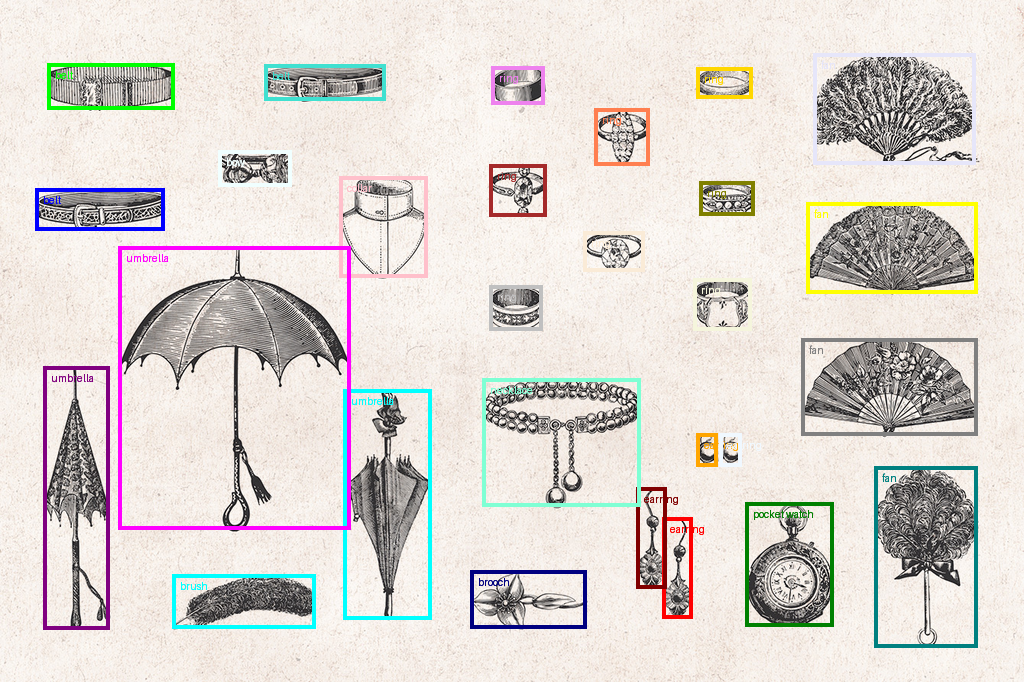

In [73]:
plot_bounding_boxes(im, response.text)
im

Mettons tout ceci dans une fonction pour plus d'aisance : 

In [68]:
def extract_object_vlm(image_path):
    prompt = "Detect the 2d bounding boxes of the different objects in this engraving (with “label” as topping description”)"  # @param {type:"string"}

    image = image_path


    im = Image.open(BytesIO(open(image, "rb").read()))
    im.thumbnail([1024,1024], Image.Resampling.LANCZOS)

    # Run model to find bounding boxes
    response = client.models.generate_content(
        model="gemini-3-flash-preview",
        contents=[prompt, im],
        config = types.GenerateContentConfig(
            temperature=0.5,
            thinking_config=types.ThinkingConfig(
            thinking_budget=0
            )
        )
    )
    
    plot_bounding_boxes(im, response.text)
    return im
    

In [74]:
extract_object_vlm('./data/cours_14-04/cinema.jpeg')

ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}

In [ ]:
extract_object_vlm('./data/cours_23-03/piero/31402.jpg')

❓ Quels peuvent-être les avantages et inconvénients de ces VLMs ?

*Votre réponse*

# Partie 3 - Extraire les bounding boxes

In [7]:
from io import BytesIO

In [32]:
prompt = "For each person in this engraving detect their pose and return the points that draw their posture"  # @param {type:"string"}

image_path = './data/cours_23-03/piero/31391.jpg'
# Load and resize image
im = Image.open(BytesIO(open(image_path, "rb").read()))
#im.thumbnail([1024,1024], Image.Resampling.LANCZOS)

# Run model to find bounding boxes
response = client.models.generate_content(
    model="gemini-3-flash-preview",
    contents=[prompt, im],
    config = types.GenerateContentConfig(
        temperature=0.5,
        thinking_config=types.ThinkingConfig(
          thinking_budget=0
        )
    )
)


In [33]:
keypoints = eval(parse_json(response.text).replace('\n ','').replace('`','').replace('json','').replace('\n','').replace(']]',']'))

In [34]:
keypoints

([{'point': [343, 303], 'label': 'nose'},
  {'point': [363, 321], 'label': 'left_eye'},
  {'point': [358, 298], 'label': 'right_eye'},
  {'point': [368, 349], 'label': 'left_ear'},
  {'point': [365, 252], 'label': 'right_ear'},
  {'point': [435, 381], 'label': 'left_shoulder'},
  {'point': [434, 219], 'label': 'right_shoulder'},
  {'point': [555, 412], 'label': 'left_elbow'},
  {'point': [565, 148], 'label': 'right_elbow'},
  {'point': [615, 362], 'label': 'left_wrist'},
  {'point': [626, 201], 'label': 'right_wrist'},
  {'point': [651, 381], 'label': 'left_hip'},
  {'point': [655, 237], 'label': 'right_hip'},
  {'point': [763, 314], 'label': 'left_knee'},
  {'point': [743, 314], 'label': 'right_knee'},
  {'point': [899, 252], 'label': 'left_ankle'},
  {'point': [862, 222], 'label': 'right_ankle'}],
 [{'point': [343, 592], 'label': 'nose'},
  {'point': [334, 613], 'label': 'left_eye'},
  {'point': [334, 599], 'label': 'right_eye'},
  {'point': [338, 665], 'label': 'left_ear'},
  {'poin

In [39]:
im.shape

(1112, 900, 3)

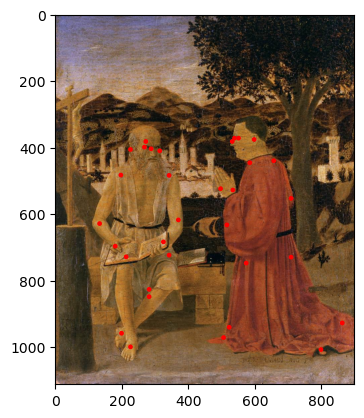

In [40]:
im = cv2.imread(image_path)
im = cv2.cvtColor(im,cv2.COLOR_BGR2RGB)
fig, ax = plt.subplots(1)
ax.imshow(im)


for person in keypoints:
    for keypoint in person:
        abs_y1 = int(keypoint["point"][0]/1000 * im.shape[0])
        abs_x1 = int(keypoint["point"][1]/1000 * im.shape[1])
        ax.add_patch(plt.Circle((abs_x1,abs_y1), 5, color='r'))


In [21]:

def plot_keypoints(im, keypoints):
    """
    Plots bounding boxes on an image with markers for each a name, using PIL, normalized coordinates, and different colors.

    Args:
        img_path: The path to the image file.
        bounding_boxes: A list of bounding boxes containing the name of the object
         and their positions in normalized [y1 x1 y2 x2] format.
    """

    # Load the image
    img = im
    width, height = img.size
    print(img.size)
    # Create a drawing object
    draw = ImageDraw.Draw(img)

    # Parsing out the markdown fencing
    keypoints = parse_json(keypoints.replace('\n ',''))


    # Iterate over the bounding boxes
    for i, keypoint in enumerate(json.loads(keypoints)):

      # Convert normalized coordinates to absolute coordinates
      abs_y1 = int(keypoint["point"][0]/1000 * height)
      abs_x1 = int(keypoint["point"][1]/1000 * width)
      # Draw the bounding box
      draw.circle(
          (abs_x1, abs_y1), radius=5, outline='red', width=4
      )

      # Draw the text
      if "label" in keypoint:
        draw.text((abs_x1 + 8, abs_y1 + 6), keypoint["label"], fill='red')

    # Display the image
    img.show()